In [117]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pymongo import MongoClient


In [118]:
def load_env_variables(env_file_path: str) -> dict:
    """Load KEY=VALUE pairs from env file for secure configuration generado por ia"""
    # generado por ia
    env_path = Path(env_file_path)
    env_data = {}
    if not env_path.exists():
        return env_data
    for raw_line in env_path.read_text().splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#'):
            continue
        if '=' in line:
            key, value = line.split('=', 1)
            env_data[key.strip()] = value.strip()
    return env_data

def get_mongo_client(mongo_url: str) -> MongoClient:
    """Return a MongoClient using the provided connection string generado por ia"""
    # generado por ia
    return MongoClient(mongo_url)


In [119]:
env_variables = load_env_variables('.env')
mongo_connection_url = env_variables.get('MONGO_URL')
if not mongo_connection_url:
    raise ValueError('MONGO_URL is missing from the .env file')

mongo_client = get_mongo_client(mongo_connection_url)
sismos_database = mongo_client['sismosdb']
sismos_collection = sismos_database['sismos']
raw_records = list(sismos_collection.find())
sismos_dataframe = pd.DataFrame(raw_records)
if '_id' in sismos_dataframe.columns:
    sismos_dataframe.drop(columns='_id', inplace=True)

sismos_dataframe.head()


,codigo,magnitud,tipoMagnitud,lugar,profundidadKm,tsunami,red,sentidos,estado,fechaHora,fuentes,estaciones,ubicacion,alerta
0,ak600000001,7.8,mw,"Tokyo, Japan",12.0,False,ak,3112,automatic,2026-03-16 15:13:00,"[uu, hv]","[{'codigo': 'II.KIV', 'distanciaKm': 221, 'mag...","{'type': 'Point', 'coordinates': [37.341371, 5...",NaN
1,ak600000002,6.3,mw,"Santiago, Chile",375.4,False,pr,2656,automatic,2026-08-02 11:39:00,[uu],"[{'codigo': 'IU.COLA', 'distanciaKm': 300, 'ma...","{'type': 'Point', 'coordinates': [-168.443912,...",NaN
2,ak600000003,2.6,mwr,"Mexico City, Mexico",147.8,False,nc,3271,reviewed,2026-08-18 03:23:00,[us],"[{'codigo': 'HV.HILO', 'distanciaKm': 207, 'ma...","{'type': 'Point', 'coordinates': [3.429466, -7...",green
3,ak600000004,0.9,mwr,"Tokyo, Japan",76.8,False,uu,2444,automatic,2026-11-04 09:46:00,[hv],"[{'codigo': 'II.KIV', 'distanciaKm': 202, 'mag...","{'type': 'Point', 'coordinates': [94.503888, 7...",NaN
4,ak600000005,6.7,ml,"Wellington, New Zealand",371.3,True,uu,566,automatic,2026-01-15 04:22:00,[pr],"[{'codigo': 'IU.COLA', 'distanciaKm': 162, 'ma...","{'type': 'Point', 'coordinates': [-8.898344, 8...",NaN


In [120]:
def clean_sismos_dataframe(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Clean raw earthquake DataFrame to ensure required fields present generado por ia"""
    # generado por ia
    cleaned_df = raw_df.copy()
    required_fields = ['magnitud', 'lugar', 'profundidad']
    for field in ['magnitud', 'lugar', 'profundidad']:
        if field not in cleaned_df.columns:
            cleaned_df[field] = np.nan
    if 'profundidadKm' in cleaned_df.columns:
        cleaned_df['profundidad'] = cleaned_df['profundidad'].combine_first(cleaned_df['profundidadKm'])
    if 'ubicacion' in cleaned_df.columns:
        coordinates = cleaned_df['ubicacion'].apply(lambda value: value.get('coordinates') if isinstance(value, dict) else None)
        cleaned_df['longitude'] = coordinates.apply(lambda coord: coord[0] if coord and len(coord) >= 1 else np.nan)
        cleaned_df['latitude'] = coordinates.apply(lambda coord: coord[1] if coord and len(coord) >= 2 else np.nan)
    if 'latitude' not in cleaned_df.columns:
        cleaned_df['latitude'] = np.nan
    if 'longitude' not in cleaned_df.columns:
        cleaned_df['longitude'] = np.nan
    cleaned_df['magnitud'] = pd.to_numeric(cleaned_df['magnitud'], errors='coerce')
    cleaned_df['profundidad'] = pd.to_numeric(cleaned_df['profundidad'], errors='coerce')
    cleaned_df['latitude'] = pd.to_numeric(cleaned_df['latitude'], errors='coerce')
    cleaned_df['longitude'] = pd.to_numeric(cleaned_df['longitude'], errors='coerce')
    cleaned_df = cleaned_df.dropna(subset=required_fields + ['latitude', 'longitude'])
    cleaned_df['lugar'] = cleaned_df['lugar'].astype(str).str.strip()
    cleaned_df = cleaned_df[cleaned_df['lugar'].astype(bool)].reset_index(drop=True)
    dedup_columns = [field for field in required_fields + ['latitude', 'longitude'] if field in cleaned_df.columns]
    cleaned_df = cleaned_df.drop_duplicates(subset=dedup_columns, ignore_index=True)
    return cleaned_df

cleaned_sismos = clean_sismos_dataframe(sismos_dataframe)
cleaned_sismos.info()
cleaned_sismos.head()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   codigo         1000 non-null   str           
 1   magnitud       1000 non-null   float64       
 2   tipoMagnitud   1000 non-null   str           
 3   lugar          1000 non-null   str           
 4   profundidadKm  1000 non-null   float64       
 5   tsunami        1000 non-null   bool          
 6   red            1000 non-null   str           
 7   sentidos       1000 non-null   int64         
 8   estado         1000 non-null   str           
 9   fechaHora      1000 non-null   datetime64[us]
 10  fuentes        1000 non-null   object        
 11  estaciones     1000 non-null   object        
 12  ubicacion      1000 non-null   object        
 13  alerta         189 non-null    str           
 14  profundidad    1000 non-null   float64       
 15  longitude      1000 non-null   fl

,codigo,magnitud,tipoMagnitud,lugar,profundidadKm,tsunami,red,sentidos,estado,fechaHora,fuentes,estaciones,ubicacion,alerta,profundidad,longitude,latitude
0,ak600000001,7.8,mw,"Tokyo, Japan",12.0,False,ak,3112,automatic,2026-03-16 15:13:00,"[uu, hv]","[{'codigo': 'II.KIV', 'distanciaKm': 221, 'mag...","{'type': 'Point', 'coordinates': [37.341371, 5...",NaN,12.0,37.341371,55.283089
1,ak600000002,6.3,mw,"Santiago, Chile",375.4,False,pr,2656,automatic,2026-08-02 11:39:00,[uu],"[{'codigo': 'IU.COLA', 'distanciaKm': 300, 'ma...","{'type': 'Point', 'coordinates': [-168.443912,...",NaN,375.4,-168.443912,-33.218451
2,ak600000003,2.6,mwr,"Mexico City, Mexico",147.8,False,nc,3271,reviewed,2026-08-18 03:23:00,[us],"[{'codigo': 'HV.HILO', 'distanciaKm': 207, 'ma...","{'type': 'Point', 'coordinates': [3.429466, -7...",green,147.8,3.429466,-73.636306
3,ak600000004,0.9,mwr,"Tokyo, Japan",76.8,False,uu,2444,automatic,2026-11-04 09:46:00,[hv],"[{'codigo': 'II.KIV', 'distanciaKm': 202, 'mag...","{'type': 'Point', 'coordinates': [94.503888, 7...",NaN,76.8,94.503888,7.088225
4,ak600000005,6.7,ml,"Wellington, New Zealand",371.3,True,uu,566,automatic,2026-01-15 04:22:00,[pr],"[{'codigo': 'IU.COLA', 'distanciaKm': 162, 'ma...","{'type': 'Point', 'coordinates': [-8.898344, 8...",NaN,371.3,-8.898344,8.964647


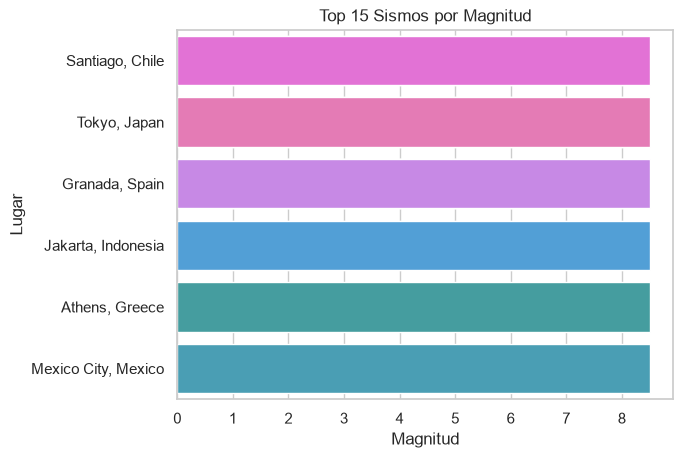

In [121]:
# Top 15 sismos por magnitud
top_mag = cleaned_sismos.nlargest(15, 'magnitud').sort_values('magnitud', ascending=True)
sns.set(style='whitegrid')
plot = sns.barplot(data=top_mag, x='magnitud', y='lugar', hue='fechaHora', dodge=False)
plot.set(title='Top 15 Sismos por Magnitud', xlabel='Magnitud', ylabel='Lugar')
plot.legend([],[], frameon=False)


Text(0, 0.5, 'Lugar')

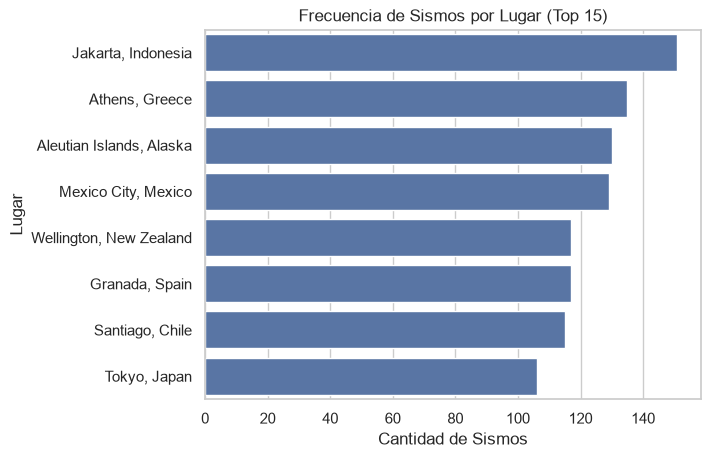

In [122]:
# Ranking de ciudades/países por número de sismos
import matplotlib.pyplot as plt
top_places = cleaned_sismos['lugar'].value_counts().head(15)
sns.barplot(y=top_places.index, x=top_places.values)
plt.title('Frecuencia de Sismos por Lugar (Top 15)')
plt.xlabel('Cantidad de Sismos')
plt.ylabel('Lugar')


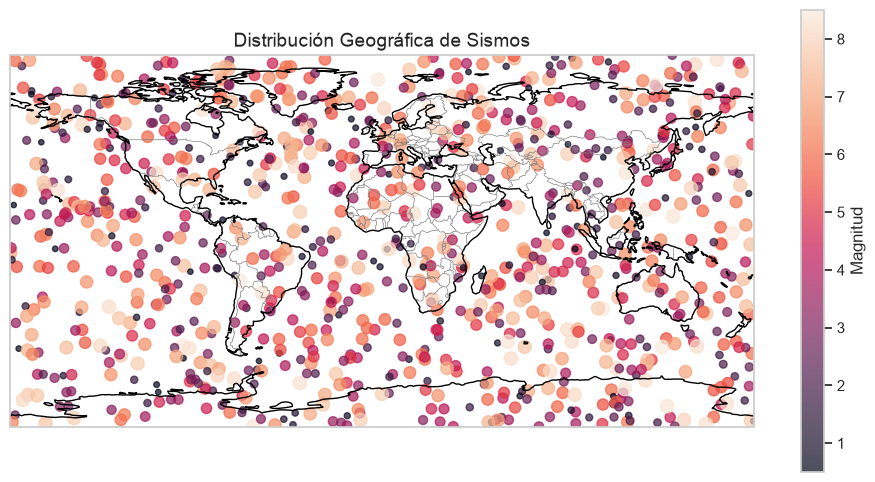

In [123]:
# Mapa scatter simple usando matplotlib + seaborn
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.figure(figsize=(12,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines(resolution='110m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
ax.set_title('Distribución Geográfica de Sismos', fontsize=14)

# Graficar los puntos usando seaborn o plt.scatter
sc = ax.scatter(
    cleaned_sismos['longitude'],
    cleaned_sismos['latitude'],
    c=cleaned_sismos['magnitud'],
    cmap='rocket',
    alpha=0.7,
    s=10 + 10* cleaned_sismos['magnitud'],  # tamaño relativo a magnitud
    transform=ccrs.PlateCarree()
)

cb = plt.colorbar(sc, ax=ax, orientation='vertical', label='Magnitud')
plt.show()
